<h2><b>Image Processing and Machine Vision - Assignmet 01</b></h2>



1.Implimentation of the intesity transformation


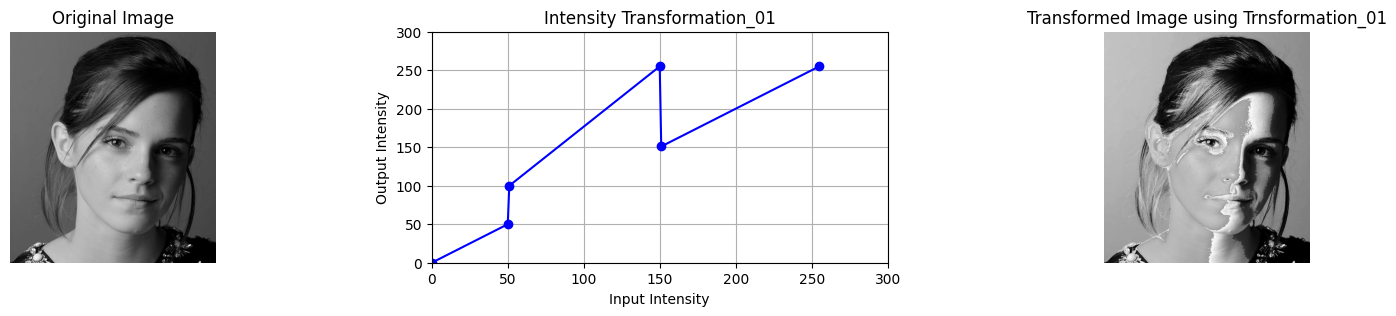

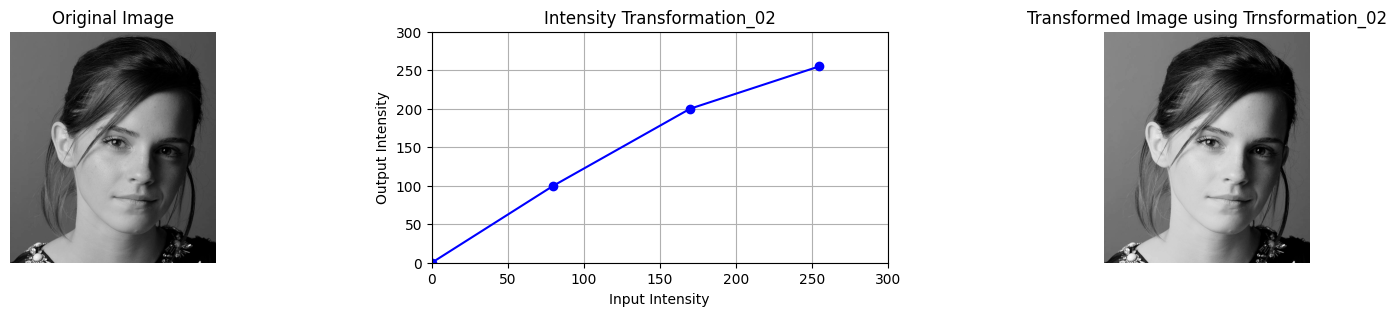

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

breakpoints_1 = [[0,0], [50,50], [51,100], [150,255], [151,151],[255,255]]
breakpoints_2 = [[0, 0], [80, 100], [170, 200], [255, 255]]

x_coords_1 = [x[0] for x in breakpoints_1] # Extracting x-coordinates from the breakpoints_1
y_coords_1 = [x[1] for x in breakpoints_1] # Extracting y-coordinates from the breakpoints_1

x_coords_2 = [x[0] for x in breakpoints_2] # Extracting x-coordinates from the breakpoints_2
y_coords_2 = [x[1] for x in breakpoints_2] # Extracting y-coordinates from the breakpoints_2

def intensity_transform(im, breakpoints):
   
    # Separate into input (x) and output (y) coordinates
    x_coords = [x[0] for x in breakpoints]
    y_coords = [x[1] for x in breakpoints]

    # Apply numpy's linear interpolation
    # im.flatten() makes the 2D image a 1D array so interp can process it
    transformed_flat = np.interp(im.flatten(), x_coords, y_coords)
    
    # Reshape it back to the original image dimensions and ensure it's an 8-bit integer
    transformed_im = transformed_flat.reshape(im.shape).astype(np.uint8)
    
    return transformed_im

im = cv.imread("C:\\Users\\USER\\Desktop\\UNI\\Semesters\\Semester 5\\Machine_Vision\\Image-Processing-and-Machine-Vision\\images\\q1.jpeg", cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found or unable to open."
transformed_imm_1 = intensity_transform(im, breakpoints_1)

fig , ax = plt.subplots(1,3,figsize = (20,3))
ax[0].imshow(im, cmap = 'gray', vmin = 0, vmax = 255)
ax[0].set_title('Original Image')
ax[0].axis('off')  # Hide axes for the original image


ax[1].plot(x_coords_1, y_coords_1, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation_01')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints

ax[2].imshow(transformed_imm_1, cmap = 'gray', vmin = 0, vmax = 255)
ax[2].set_title('Transformed Image using Trnsformation_01')
ax[2].axis('off')  # Hide axes for the transformed image

transformed_imm_2 = intensity_transform(im, breakpoints_2)
fig , ax = plt.subplots(1,3,figsize = (20,3))

ax[0].imshow(im, cmap = 'gray', vmin = 0, vmax = 255)
ax[0].set_title('Original Image')
ax[0].axis('off')  # Hide axes for the original image

ax[1].plot(x_coords_2, y_coords_2, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation_02')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints

ax[2].imshow(transformed_imm_2, cmap = 'gray', vmin = 0, vmax = 255)
ax[2].set_title('Transformed Image using Trnsformation_02')
ax[2].axis('off')  # Hide axes for the transformed image

plt.show()

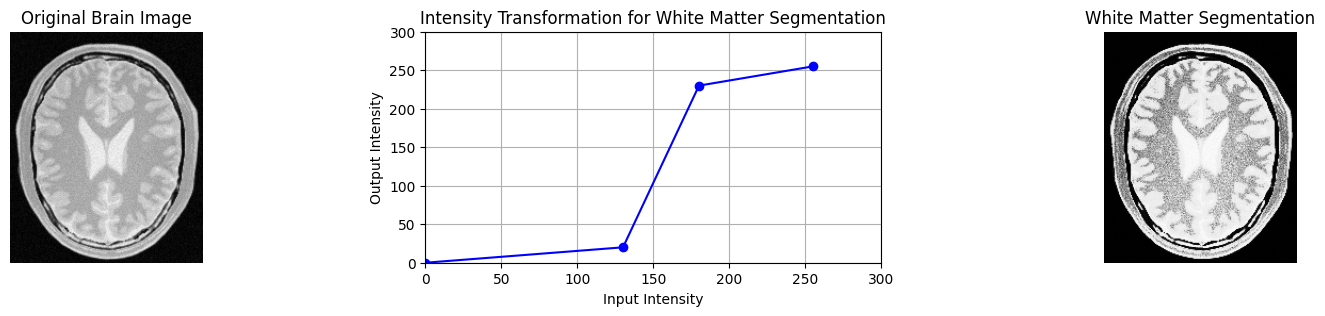

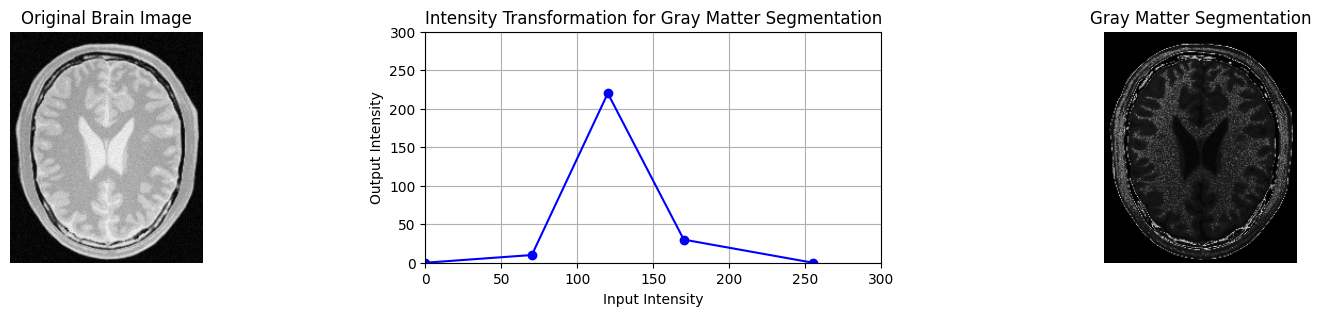

In [2]:
# Breakpoints targeting high intensities (White Matter)
wm_breakpoints = [
    [0, 0],
    [130, 20],   # Suppress CSF(Cerebral Spinal Fluid) and Gray Matter
    [180, 230],  # Steep stretch across White Matter range
    [255, 255]   # Max out bright regions
]
x_coords_wm = [x[0] for x in wm_breakpoints] # Extracting x-coordinates from the wm_breakpoints
y_coords_wm = [x[1] for x in wm_breakpoints] # Extracting y-coordinates from the wm_breakpoints

im_brain = cv.imread("C:\\Users\\USER\\Desktop\\UNI\\Semesters\\Semester 5\\Machine_Vision\\Image-Processing-and-Machine-Vision\\images\\q2.jpeg", cv.IMREAD_GRAYSCALE)
wm_image = intensity_transform(im_brain, wm_breakpoints)

fig, ax = plt.subplots (1, 3, figsize=(20, 3))
ax[0].imshow(im_brain, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Brain Image')     
ax[0].axis('off')  # Hide axes for the original image

ax[1].plot(x_coords_wm, y_coords_wm, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation for White Matter Segmentation')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints


ax[2].imshow(wm_image, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('White Matter Segmentation')
ax[2].axis('off')  # Hide axes for the transformed image

plt.show()

# Breakpoints targeting mid intensities (Gray Matter)
gm_breakpoints = [
    [0, 0],
    [70, 10],    # Suppress dark background / CSF
    [120, 220],  # Steep stretch across Gray Matter range
    [170, 30],   # Drop bright White Matter to keep Gray Matter visually dominant
    [255, 0]
]

x_coords_gm = [x[0] for x in gm_breakpoints] # Extracting x-coordinates from the gm_breakpoints
y_coords_gm = [x[1] for x in gm_breakpoints] # Extracting y-coordinates from the gm_breakpoints

gm_image = intensity_transform(im_brain, gm_breakpoints)
fig, ax = plt.subplots (1, 3, figsize=(20, 3))
ax[0].imshow(im_brain, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Brain Image')     
ax[0].axis('off')  # Hide axes for the original image

ax[1].plot(x_coords_gm, y_coords_gm, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation for Gray Matter Segmentation')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints


ax[2].imshow(gm_image, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Gray Matter Segmentation')
ax[2].axis('off')  # Hide axes for the transformed image

plt.show()




2. Gamma correction to L plane

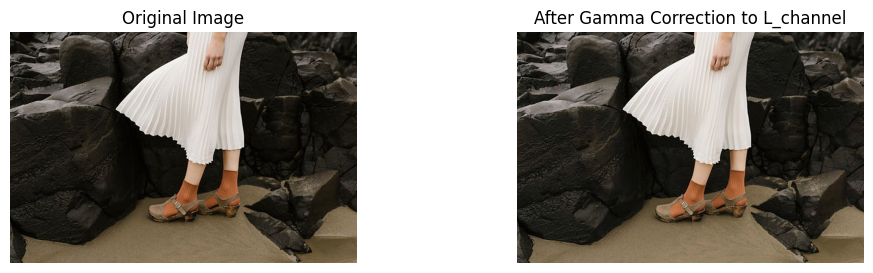

In [15]:
im = cv.imread("C:\\Users\\USER\\Desktop\\UNI\\Semesters\\Semester 5\\Machine_Vision\\Image-Processing-and-Machine-Vision\\images\\3.jpeg")
im_LAB = cv.cvtColor(im,cv.COLOR_BGR2LAB)

fig,ax = plt.subplots(1,2,figsize = (12,3))
ax[0].imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

l_plane, a_plane, b_plane = cv.split(im_LAB)
gamma = 0.9
lut = np.array([((i/255.0)**gamma)*255 for i in range(0,256)]).astype("uint8")
l_corrected = cv.LUT(l_plane,lut)

im_LAB_corrected = cv.merge((l_corrected,a_plane,b_plane))


ax[1].imshow(cv.cvtColor(im_LAB_corrected,cv.COLOR_LAB2RGB))
ax[1].set_title('After Gamma Correction to L_channel')
ax[1].axis('off')


plt.show()


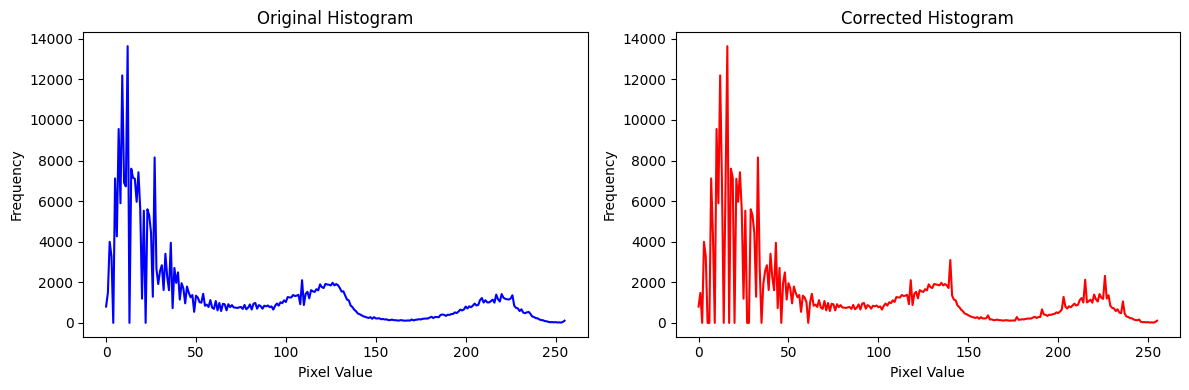

In [18]:
hist_orig = cv.calcHist([l_plane],[0],None,[256],[0,256])
hist_corr = cv.calcHist([l_corrected],[0],None,[256],[0,256])
fig,ax = plt.subplots(1,2,figsize = (12,4))
ax[0].plot(hist_orig, color='blue')
ax[0].set_title('Original Histogram')
ax[0].set_xlabel('Pixel Value')
ax[0].set_ylabel('Frequency')

ax[1].plot(hist_corr, color='red')
ax[1].set_title('Corrected Histogram')
ax[1].set_xlabel('Pixel Value')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()